In [358]:
! pip install "granite-tsfm[notebooks]==0.3.1"
! pip install gdown


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [359]:
import math
import os

import numpy as np
import pandas as pd
import torch
import evaluate
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import Subset
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, set_seed

import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

from tsfm_public.models.tspulse import TSPulseForReconstruction
from tsfm_public.toolkit.dataset import PretrainDFDataset
from tsfm_public import get_datasets
from tsfm_public.toolkit.ad_helpers import AnomalyScoreMethods
from tsfm_public.toolkit.time_series_anomaly_detection_pipeline import TimeSeriesAnomalyDetectionPipeline
from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor, prepare_data_splits

## Load data from carOBD

In [360]:
path = "/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/data/carOBD/obdiidata" 
time_col = 'ENGINE_RUN_TINE ()'

df_list = []
for file in os.listdir(path):
  if file.endswith('.csv'):
    df = pd.read_csv(f'{path}/{file}', index_col=False)
    df['filename'] = file
    df_list.append(df)

print(f'{len(df_list)} files loaded out of {len([f for f in os.listdir(path) if f.endswith(".csv")])}')


129 files loaded out of 129


## Remove zero-variance columns

In [361]:
def remove_zero_variance_columns(df: pd.DataFrame) -> pd.DataFrame:
  """
  Compute std of each std-computable column (numeric only)
  """
  std_df = df.std(numeric_only=True)

  zero_variance_cols = std_df[std_df == 0].index.tolist()
  print(f'{len(zero_variance_cols)} columns with zero variance')

  if len(zero_variance_cols) > 0:
    df = df.drop(columns=zero_variance_cols)

  return df

## Handle missing Timestamps and duplicates

In [362]:
def mean_fill_missing_timestamps_and_remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
  """
  Remove duplicate timestamps by averaging all numeric columns for each unique timestamp.
  This preserves the overall statistics while removing duplicate entries.
  
  Note: The time column itself is not averaged (it becomes the group key).
  Only numeric columns are averaged when multiple rows share the same timestamp.
  """
  df = df.groupby(time_col, as_index=False).mean(numeric_only=True)
  return df

## Inject Anomalies

In [363]:
from typing import Tuple, Dict, Optional, List

def create_realistic_fault_data(
    normal_data: np.ndarray, 
    fault_percentage: float = 0.2,
    random_state: Optional[int] = None,
    fault_types: Optional[List[str]] = None
) -> Tuple[np.ndarray, np.ndarray, Dict]:
    if fault_types is None:
        fault_types = ['coolant_bias', 'coolant_drift', 'coolant_stuck', 'rpm_bias', 'multi_sensor']
    
    if random_state is not None:
        np.random.seed(random_state)
    
    n_samples = len(normal_data)
    n_faults = int(n_samples * fault_percentage)
    
    fault_labels = np.zeros(n_samples, dtype=int)
    fault_indices = np.random.choice(n_samples, n_faults, replace=False)
    fault_labels[fault_indices] = 1
    fault_features = normal_data.copy()
    
    fault_type_list = [None] * n_samples
    original_values = [[] for _ in range(n_samples)]
    modified_values = [[] for _ in range(n_samples)]
    
    for idx in fault_indices:
        fault_type = np.random.choice(fault_types)
        fault_type_list[idx] = fault_type
        
        if fault_type == 'coolant_bias':
            bias_amount = np.random.uniform(40, 80) * np.random.choice([-1, 1])
            original_val = fault_features[idx, 0]
            fault_features[idx, 0] += bias_amount
            original_values[idx].append(original_val)
            modified_values[idx].append(fault_features[idx, 0])
        
        elif fault_type == 'coolant_drift':
            drift_factor = np.random.uniform(0.6, 1.4)
            original_val = fault_features[idx, 0]
            fault_features[idx, 0] *= drift_factor
            original_values[idx].append(original_val)
            modified_values[idx].append(fault_features[idx, 0])
            
            if fault_features.shape[1] > 1:
                rpm_factor = np.random.uniform(0.7, 1.3)
                original_rpm = fault_features[idx, 1]
                fault_features[idx, 1] *= rpm_factor
                original_values[idx].append(original_rpm)
                modified_values[idx].append(fault_features[idx, 1])
        
        elif fault_type == 'coolant_stuck':
            stuck_temp = np.random.uniform(10, 150)
            original_val = fault_features[idx, 0]
            fault_features[idx, 0] = stuck_temp
            original_values[idx].append(original_val)
            modified_values[idx].append(stuck_temp)
        
        elif fault_type == 'rpm_bias':
            rpm_bias = np.random.uniform(300, 1000) * np.random.choice([-1, 1])
            if fault_features.shape[1] > 1:
                original_rpm = fault_features[idx, 1]
                fault_features[idx, 1] += rpm_bias
                original_values[idx].append(original_rpm)
                modified_values[idx].append(fault_features[idx, 1])
        
        elif fault_type == 'multi_sensor':
            degradation_factor = np.random.uniform(0.5, 1.5)
            original_vals_copy = fault_features[idx].copy()
            fault_features[idx] *= degradation_factor
            noise_level = np.random.uniform(0.15, 0.3)
            fault_features[idx] += np.random.normal(0, noise_level, fault_features.shape[1])
            
            for col_idx in range(fault_features.shape[1]):
                original_values[idx].append(original_vals_copy[col_idx])
                modified_values[idx].append(fault_features[idx, col_idx])
    
    fault_info = {
        'fault_types': fault_type_list,
        'original_values': original_values,
        'modified_values': modified_values,
        'n_faults': n_faults,
        'fault_percentage': fault_percentage
    }
    
    return fault_features, fault_labels, fault_info

## Standardization

In [364]:
from sklearn.preprocessing import StandardScaler

def scale_data(normal_data: np.ndarray, fault_data: np.ndarray = None) -> Tuple[np.ndarray, StandardScaler, np.ndarray]:
    scaler = StandardScaler()
    normal_scaled = scaler.fit_transform(normal_data)
    
    if fault_data is not None:
        fault_scaled = scaler.transform(fault_data)
        return normal_scaled, scaler, fault_scaled
    
    return normal_scaled, scaler, None

## Process Data

In [365]:
target_columns = [
    'COOLANT_TEMPERATURE ()',
    'ENGINE_RPM ()',
    'VEHICLE_SPEED ()',
    'THROTTLE ()',
    'ENGINE_LOAD ()',
    'INTAKE_MANIFOLD_PRESSURE ()',
]

all_file_data = skipped_files = []

def process_file(df, target_columns):
    """Process a single file and return data + masks with VALIDATION"""
    df_clean = mean_fill_missing_timestamps_and_remove_duplicates(df)
    
    missing_cols = [col for col in target_columns if col not in df_clean.columns]
    if missing_cols:
        print(f"⚠️  File missing columns: {missing_cols}")
        return None
    
    try:
        data = df_clean[target_columns].values.astype(np.float32)
    except KeyError as e:
        print(f"⚠️  Error extracting columns: {e}")
        return None
    
    return data

print("Processing all files...")
all_file_data = []

for idx, df in enumerate(df_list):
    data = process_file(df, target_columns)
    
    if data is None:
        skipped_files.append(idx)
        print(f"❌ Skipped file {idx}")
        continue
    
    # Validate dimensions
    assert data.shape[1] == len(target_columns), f"File {idx}: Expected {len(target_columns)} channels, got {data.shape[1]}"
    
    all_file_data.append({
        'file_idx': idx,
        'data': data,
        'n_samples': len(data)
    })
    print(f"✓ File {idx}: {len(data)} samples, shape {data.shape}")

print(f"\nTotal files: {len(all_file_data)}")
print(f"Skipped files: {len(skipped_files)}")
print(f"Total samples: {sum(f['n_samples'] for f in all_file_data)}")    

Processing all files...
✓ File 0: 617 samples, shape (617, 6)
✓ File 1: 722 samples, shape (722, 6)
✓ File 2: 512 samples, shape (512, 6)
✓ File 3: 1111 samples, shape (1111, 6)
✓ File 4: 350 samples, shape (350, 6)
✓ File 5: 397 samples, shape (397, 6)
✓ File 6: 619 samples, shape (619, 6)
✓ File 7: 626 samples, shape (626, 6)
✓ File 8: 957 samples, shape (957, 6)
✓ File 9: 349 samples, shape (349, 6)
✓ File 10: 504 samples, shape (504, 6)
✓ File 11: 265 samples, shape (265, 6)
✓ File 12: 368 samples, shape (368, 6)
✓ File 13: 1041 samples, shape (1041, 6)
✓ File 14: 1482 samples, shape (1482, 6)
✓ File 15: 343 samples, shape (343, 6)
✓ File 16: 837 samples, shape (837, 6)
✓ File 17: 640 samples, shape (640, 6)
✓ File 18: 1099 samples, shape (1099, 6)
✓ File 19: 2039 samples, shape (2039, 6)
✓ File 20: 576 samples, shape (576, 6)
✓ File 21: 1029 samples, shape (1029, 6)
✓ File 22: 346 samples, shape (346, 6)
✓ File 23: 885 samples, shape (885, 6)
✓ File 24: 297 samples, shape (297, 6)

In [366]:
def create_windows_from_files_clean(file_indices, all_clean_data, context_length, stride):
    """Create windows WITHOUT masks (clean data only)"""
    all_windows = []
    file_sources = []
    
    for file_idx in file_indices:
        file_data = all_clean_data[file_idx]
        data = file_data['data']
        
        if len(data) < context_length:
            print(f"⚠️  Skipping file {file_idx}: too short ({len(data)} < {context_length})")
            continue
        
        # Create windows
        for start_idx in range(0, len(data) - context_length + 1, stride):
            end_idx = start_idx + context_length
            all_windows.append(data[start_idx:end_idx])
            file_sources.append(file_idx)
        
        # Handle last window
        last_start = len(data) - context_length
        if last_start not in range(0, len(data) - context_length + 1, stride):
            window_data = data[last_start:]
            if len(window_data) < context_length:
                pad_len = context_length - len(window_data)
                window_data = np.vstack([window_data, np.zeros((pad_len, data.shape[1]))])
            all_windows.append(window_data)
            file_sources.append(file_idx)
    
    return np.array(all_windows), file_sources

In [367]:
## Split and Inject Faults
from sklearn.model_selection import train_test_split

context_length = 512
prediction_length = 16
stride = 64

file_indices = list(range(len(all_file_data)))
train_file_indices, val_file_indices = train_test_split(
    file_indices, 
    test_size=0.2, 
    random_state=42
)

train_windows_clean, train_sources = create_windows_from_files_clean(
    train_file_indices, all_file_data, context_length, stride
)

val_windows_clean, val_sources = create_windows_from_files_clean(
    val_file_indices, all_file_data, context_length, stride
)
    

⚠️  Skipping file 12: too short (368 < 512)
⚠️  Skipping file 127: too short (383 < 512)
⚠️  Skipping file 24: too short (297 < 512)
⚠️  Skipping file 89: too short (401 < 512)
⚠️  Skipping file 15: too short (343 < 512)
⚠️  Skipping file 77: too short (500 < 512)
⚠️  Skipping file 22: too short (346 < 512)
⚠️  Skipping file 44: too short (379 < 512)
⚠️  Skipping file 30: too short (198 < 512)
⚠️  Skipping file 62: too short (391 < 512)
⚠️  Skipping file 122: too short (505 < 512)
⚠️  Skipping file 9: too short (349 < 512)
⚠️  Skipping file 66: too short (493 < 512)
⚠️  Skipping file 25: too short (215 < 512)
⚠️  Skipping file 98: too short (368 < 512)
⚠️  Skipping file 5: too short (397 < 512)
⚠️  Skipping file 73: too short (304 < 512)
⚠️  Skipping file 123: too short (219 < 512)
⚠️  Skipping file 34: too short (311 < 512)
⚠️  Skipping file 43: too short (324 < 512)
⚠️  Skipping file 76: too short (308 < 512)
⚠️  Skipping file 104: too short (376 < 512)
⚠️  Skipping file 72: too shor

## Metrics

In [368]:
from evaluate import load

metric = load("f1")

In [369]:
## Visualization Function

def plot_anomaly_detection(
    results: pd.DataFrame,
    timestamp_column: str,
    target_columns: list,
    ground_truth_labels: np.ndarray = None,
    threshold: float = 0.5,
    figsize: tuple = (15, 12)
):
    anomaly_scores = results['anomaly_score'].values
    predicted_anomalies = anomaly_scores >= threshold
    
    if ground_truth_labels is not None:
        injected_anomalies = ground_truth_labels == 1
        tp = (injected_anomalies & predicted_anomalies).sum()
        fp = (~injected_anomalies & predicted_anomalies).sum()
        fn = (injected_anomalies & ~predicted_anomalies).sum()
        tn = (~injected_anomalies & ~predicted_anomalies).sum()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    n_plots = len(target_columns) + 2 if ground_truth_labels is not None else len(target_columns) + 1
    fig, axes = plt.subplots(n_plots, 1, figsize=figsize)
    fig.suptitle('Anomaly Detection: Injected vs Predicted', fontsize=16, fontweight='bold')
    
    if n_plots == 1:
        axes = [axes]
    
    for idx, col in enumerate(target_columns):
        if col not in results.columns:
            continue
        ax = axes[idx]
        ax.plot(results[timestamp_column], results[col], label=col, alpha=0.6, linewidth=1, color='gray')
        
        if ground_truth_labels is not None:
            if injected_anomalies.sum() > 0:
                ax.scatter(
                    results[timestamp_column][injected_anomalies],
                    results[col][injected_anomalies],
                    color='red', s=40, marker='x', label='Injected', zorder=5, alpha=0.8, linewidths=2
                )
            if predicted_anomalies.sum() > 0:
                ax.scatter(
                    results[timestamp_column][predicted_anomalies],
                    results[col][predicted_anomalies],
                    color='orange', s=30, marker='o', label='Predicted', zorder=4, alpha=0.6, edgecolors='darkorange'
                )
            if tp > 0:
                tp_mask = injected_anomalies & predicted_anomalies
                ax.scatter(
                    results[timestamp_column][tp_mask],
                    results[col][tp_mask],
                    color='green', s=50, marker='*', label='True Positive', zorder=6, alpha=0.9
                )
        else:
            if predicted_anomalies.sum() > 0:
                ax.scatter(
                    results[timestamp_column][predicted_anomalies],
                    results[col][predicted_anomalies],
                    color='red', s=30, label='Anomaly', zorder=5, alpha=0.8
                )
        
        ax.set_ylabel(col, fontsize=10)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    ax = axes[-2] if ground_truth_labels is not None else axes[-1]
    ax.plot(results[timestamp_column], anomaly_scores, label='Anomaly Score', color='purple', linewidth=1)
    ax.axhline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')
    ax.set_xlabel('Time', fontsize=10)
    ax.set_ylabel('Anomaly Score', fontsize=10)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    
    if ground_truth_labels is not None:
        ax = axes[-1]
        comparison = np.zeros(len(results))
        comparison[injected_anomalies & predicted_anomalies] = 1
        comparison[injected_anomalies & ~predicted_anomalies] = 2
        comparison[~injected_anomalies & predicted_anomalies] = 3
        
        colors_map = {0: 'gray', 1: 'green', 2: 'red', 3: 'orange'}
        labels_map = {0: 'Normal', 1: 'TP', 2: 'FN', 3: 'FP'}
        
        for val in [1, 2, 3]:
            mask = comparison == val
            if mask.sum() > 0:
                ax.scatter(
                    results[timestamp_column][mask],
                    comparison[mask],
                    color=colors_map[val], s=30, label=labels_map[val], alpha=0.7
                )
        
        ax.set_xlabel('Time', fontsize=10)
        ax.set_ylabel('Classification', fontsize=10)
        ax.set_yticks([0, 1, 2, 3])
        ax.set_yticklabels(['Normal', 'TP', 'FN', 'FP'])
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n{'='*60}")
    print("Anomaly Detection Statistics")
    print(f"{'='*60}")
    print(f"Total points: {len(results):,}")
    print(f"Predicted anomalies (≥{threshold}): {predicted_anomalies.sum():,} ({predicted_anomalies.sum()/len(results)*100:.2f}%)")
    
    if ground_truth_labels is not None:
        print(f"\nGround Truth:")
        print(f"  Injected anomalies: {injected_anomalies.sum():,} ({injected_anomalies.sum()/len(results)*100:.2f}%)")
        print(f"\nConfusion Matrix:")
        print(f"  True Positives (TP):  {tp:,}")
        print(f"  False Positives (FP): {fp:,}")
        print(f"  False Negatives (FN): {fn:,}")
        print(f"  True Negatives (TN):  {tn:,}")
        print(f"\nMetrics:")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall:    {recall:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
    
    print(f"\nAnomaly Score Statistics:")
    print(f"  Min: {anomaly_scores.min():.4f}, Max: {anomaly_scores.max():.4f}")
    print(f"  Mean: {anomaly_scores.mean():.4f}, Std: {anomaly_scores.std():.4f}")
    print(f"  Percentiles - 50th: {np.percentile(anomaly_scores, 50):.4f}, 95th: {np.percentile(anomaly_scores, 95):.4f}, 99th: {np.percentile(anomaly_scores, 99):.4f}")



## Model Init

In [370]:
from tsfm_public.models.tspulse import TSPulseForReconstruction
from tsfm_public.models.tspulse.utils.helpers import PatchMaskingDatasetWrapper
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

set_seed(42)

target_columns = [
    'COOLANT_TEMPERATURE ()',
    'ENGINE_RPM ()',
    'VEHICLE_SPEED ()',
    'THROTTLE ()',
    'ENGINE_LOAD ()',
    'INTAKE_MANIFOLD_PRESSURE ()',
]

column_specifiers = {
    "timestamp_column": time_col,
    "target_columns": target_columns,
    "id_columns": [],
}

model = TSPulseForReconstruction.from_pretrained(
    "ibm-granite/granite-timeseries-tspulse-r1",
    num_input_channels=len(target_columns),
    revision='main',
    decoder_mode="common_channel", # TODO: test with more samples and mix_channel
    scaling="revin",
    mask_type="user"
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model.to(device)

# freeze backbone, and only train decoder and head since we have a small dataset

for param in model.backbone.parameters():
    param.requires_grad = False

for module in model.modules():
    if isinstance(module, (torch.nn.BatchNorm1d, torch.nn.BatchNorm2d)):
        module.eval()
        for param in module.parameters():
            param.requires_grad = False
            
for param in model.decoder_with_head.parameters():
    param.requires_grad = True

## Data Split

In [371]:
## Train / Val Split
from sklearn.model_selection import train_test_split
from tsfm_public.toolkit.dataset import PretrainDFDataset


context_length = 512  # Reduced from 512 for more windows
stride = 64  # Smaller stride for more overlap

#train_windows, train_masks, train_sources = create_windows_from_files(
#    train_file_indices, all_file_data, context_length, stride
#)

#val_windows, val_masks, val_sources = create_windows_from_files(
#    val_file_indices, all_file_data, context_length, stride
#)

print(f"Train windows: {len(train_windows)} from {len(train_file_indices)} files")
print(f"Val windows: {len(val_windows)} from {len(val_file_indices)} files")
print(f"Window shape: {train_windows[0].shape}")
print(f"Total windows: {len(train_windows) + len(val_windows)}")

train_dataset = [
    {
        'past_values': torch.FloatTensor(train_windows[i]),
        'past_observed_mask': torch.BoolTensor(train_masks[i])
    }
    for i in range(len(train_windows))
]

val_dataset = [
    {
        'past_values': torch.FloatTensor(val_windows[i]),
        'past_observed_mask': torch.BoolTensor(val_masks[i])
    }
    for i in range(len(val_windows))
]

train_file_set = set(train_file_indices)
val_file_set = set(val_file_indices)
assert len(train_file_set & val_file_set) == 0, "❌ Data leakage detected!"
print("✓ No data leakage - train and val files are completely separate")
print(f"Dataset ready: {len(train_dataset)} train samples, {len(val_dataset)} val samples")


Train windows: 383 from 103 files
Val windows: 82 from 26 files
Window shape: (512, 6)
Total windows: 465
✓ No data leakage - train and val files are completely separate
Dataset ready: 383 train samples, 82 val samples


## Train


In [372]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

# Step 1: Reload model cleanly
print("Reloading model...")
model = TSPulseForReconstruction.from_pretrained(
    "ibm-granite/granite-timeseries-tspulse-r1",
    num_input_channels=len(target_columns),
    decoder_mode="common_channel",
    scaling="revin",
    mask_type="user"
)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")
model = model.to(device)

# Step 2: Freeze backbone + ALL BatchNorm layers
print("\nFreezing backbone and BatchNorm layers...")
for param in model.backbone.parameters():
    param.requires_grad = False

# Critical: Set ALL BatchNorm to eval and freeze them
bn_count = 0
for name, module in model.named_modules():
    if isinstance(module, (torch.nn.BatchNorm1d, torch.nn.BatchNorm2d)):
        module.eval()
        module.track_running_stats = False  # Disable running stats
        for param in module.parameters():
            param.requires_grad = False
        bn_count += 1

print(f"Set {bn_count} BatchNorm layers to eval mode")

# Unfreeze decoder
for param in model.decoder_with_head.parameters():
    if param.requires_grad is not False:  # Don't unfreeze if it was frozen (BatchNorm)
        param.requires_grad = True

trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f"Trainable parameters: {sum(p.numel() for p in trainable_params):,}")

# Step 3: Create DataLoaders
def collate_fn(batch):
    """Collate function with contiguous memory"""
    return {
        'past_values': torch.stack([f['past_values'] for f in batch]).contiguous(),
        'past_observed_mask': torch.stack([f['past_observed_mask'] for f in batch]).contiguous()
    }

batch_size = 8  # Increased since we're using manual loop
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True, 
    collate_fn=collate_fn,
    drop_last=True,  # Avoid issues with batch size 1
    num_workers=0,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    collate_fn=collate_fn,
    drop_last=False,
    num_workers=0,
    pin_memory=False
)

print(f"\nDataLoaders created:")
print(f"  Train: {len(train_loader)} batches")
print(f"  Val: {len(val_loader)} batches")

# Step 4: Test forward and backward pass
print("\n" + "="*60)
print("Testing forward/backward pass...")
print("="*60)

def set_batchnorm_eval(model):
    for module in model.modules():
        if isinstance(module, (torch.nn.BatchNorm1d, torch.nn.BatchNorm2d)):
            module.eval()

try:
    model.train()
    set_batchnorm_eval(model)  # Keep BN in eval
    
    batch = next(iter(train_loader))
    test_out = model(
        past_values=batch['past_values'].to(device),
        past_observed_mask=batch['past_observed_mask'].to(device),
        return_loss=True
    )
    
    print(f"✓ Forward pass OK! Loss: {test_out.loss.item():.4f}")
    
    # Test backward
    test_out.loss.backward()
    print(f"✓ Backward pass OK!")
    
except Exception as e:
    print(f"❌ Test failed with error: {e}")
    print("\nDebugging info:")
    print(f"  Batch shapes: {batch['past_values'].shape}, {batch['past_observed_mask'].shape}")
    print(f"  Model device: {next(model.parameters()).device}")
    print(f"  Model dtype: {next(model.parameters()).dtype}")
    raise e

# Step 5: Setup optimizer and scheduler
learning_rate = 1e-4
num_epochs = 20

optimizer = AdamW(trainable_params, lr=learning_rate, weight_decay=0.01)

total_steps = len(train_loader) * num_epochs
scheduler = OneCycleLR(
    optimizer,
    max_lr=learning_rate,
    total_steps=total_steps,
    pct_start=0.1,
    anneal_strategy='cos'
)

print("\nOptimizer setup complete")
print(f"Total training steps: {total_steps}")

# Step 6: Manual training loop
print("\n" + "="*60)
print("Starting Training")
print("="*60 + "\n")

best_val_loss = float('inf')
patience = 5
patience_counter = 0
train_losses_history = []
val_losses_history = []

for epoch in range(num_epochs):
    model.train()
    set_batchnorm_eval(model)
    
    train_losses = []
    for batch_idx, batch in enumerate(train_loader):
        optimizer.zero_grad()
        
        try:
            outputs = model(
                past_values=batch['past_values'].to(device),
                past_observed_mask=batch['past_observed_mask'].to(device),
                return_loss=True
            )
            
            loss = outputs.loss
            
            # Check for NaN
            if torch.isnan(loss) or torch.isinf(loss):
                print(f"⚠️  NaN/Inf loss at batch {batch_idx}, skipping...")
                continue
            
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            
            optimizer.step()
            scheduler.step()
            
            train_losses.append(loss.item())
            
        except RuntimeError as e:
            print(f"\n❌ Error during training at batch {batch_idx}/{len(train_loader)}")
            print(f"Error: {e}")
            print(f"Batch past_values shape: {batch['past_values'].shape}")
            print(f"Batch past_mask shape: {batch['past_observed_mask'].shape}")
            
            # Debug specific layers
            print("\nChecking model state:")
            for name, module in model.named_modules():
                if isinstance(module, (torch.nn.BatchNorm1d, torch.nn.BatchNorm2d)):
                    print(f"  {name}: training={module.training}")
            
            raise e
    
    avg_train_loss = np.mean(train_losses) if train_losses else float('nan')
    
    # === VALIDATION ===
    model.eval()
    val_losses = []
    
    with torch.no_grad():
        for batch in val_loader:
            outputs = model(
                past_values=batch['past_values'].to(device),
                past_observed_mask=batch['past_observed_mask'].to(device),
                return_loss=True
            )
            val_losses.append(outputs.loss.item())
    
    avg_val_loss = np.mean(val_losses) if val_losses else float('nan')
    
    # Store history
    train_losses_history.append(avg_train_loss)
    val_losses_history.append(avg_val_loss)
    
    # Print epoch summary
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), './best_tspulse_model.pt')
        print(f"  ✓ New best model! (Val Loss: {best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n⏹️  Early stopping triggered after {epoch+1} epochs")
            break

# Load best model
print("\nLoading best model...")
model.load_state_dict(torch.load('./best_tspulse_model.pt'))
print("✅ Training complete!")

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(train_losses_history, label='Train Loss', marker='o')
plt.plot(val_losses_history, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('./training_history.png', dpi=150, bbox_inches='tight')
print("📊 Training history saved to ./training_history.png")


Reloading model...
Using device: mps

Freezing backbone and BatchNorm layers...
Set 0 BatchNorm layers to eval mode
Trainable parameters: 286,272

DataLoaders created:
  Train: 47 batches
  Val: 11 batches

Testing forward/backward pass...
✓ Forward pass OK! Loss: 181866.2812
❌ Test failed with error: required rank 4 tensor to use channels_last format

Debugging info:
  Batch shapes: torch.Size([8, 512, 6]), torch.Size([8, 512, 6])
  Model device: mps:0
  Model dtype: torch.float32


RuntimeError: required rank 4 tensor to use channels_last format

In [ ]:
import torch
import numpy as np
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt

model.eval()
model = model.to(device)

test_windows = val_windows
test_masks = val_masks

print("\n" + "="*60)
print("Computing anomaly scores on test set...")
print("="*60 + "\n")

coolant_idx = target_columns.index('COOLANT_TEMPERATURE ()')

# Storage for results
all_reconstruction_errors = []
all_coolant_errors = []
all_true_labels = []
all_reconstructions = []
all_originals = []

with torch.no_grad():
    for i in range(len(test_windows)):
        window = torch.FloatTensor(test_windows[i]).unsqueeze(0).to(device)
        mask = torch.BoolTensor(test_masks[i]).unsqueeze(0).to(device)
        
        # Get reconstruction
        outputs = model(
            past_values=window,
            past_observed_mask=mask,  # Use mask during inference to match training
            return_loss=False
        )
        
        reconstruction = outputs.reconstruction_outputs.squeeze(0).cpu()
        original = window.squeeze(0).cpu()
        
        # Store for visualization
        all_reconstructions.append(reconstruction.numpy())
        all_originals.append(original.numpy())
        
        # Compute reconstruction error
        error = torch.abs(reconstruction - original)
        
        # Overall reconstruction error (per window)
        overall_error = error.mean().item()
        all_reconstruction_errors.append(overall_error)
        
        # Coolant-specific error
        coolant_error = error[:, coolant_idx].mean().item()
        all_coolant_errors.append(coolant_error)
        
        # True label for this window (1 if any anomaly present)
        has_anomaly = (~mask.squeeze(0).cpu()).any().item()
        all_true_labels.append(int(has_anomaly))
        
        if (i + 1) % 20 == 0:
            print(f"  Processed {i+1}/{len(test_windows)} windows")

print(f"✓ Computed anomaly scores for {len(test_windows)} windows")

print("\n" + "="*60)
print("ANOMALY DETECTION METRICS")
print("="*60 + "\n")

# Convert to arrays
reconstruction_scores = np.array(all_reconstruction_errors)
coolant_scores = np.array(all_coolant_errors)
true_labels = np.array(all_true_labels)

# Check if we have both classes
if len(np.unique(true_labels)) < 2:
    print("⚠️  Warning: Only one class present in test set!")
    print(f"   Class distribution: {np.bincount(true_labels)}")
else:
    # === Using Overall Reconstruction Error ===
    print("1️⃣  Overall Reconstruction Error as Anomaly Score:")
    roc_auc_overall = roc_auc_score(true_labels, reconstruction_scores)
    ap_overall = average_precision_score(true_labels, reconstruction_scores)
    print(f"   ROC-AUC:           {roc_auc_overall:.4f}")
    print(f"   Average Precision: {ap_overall:.4f}")
    
    # === Using Coolant-Specific Error ===
    print("\n2️⃣  Coolant-Specific Error as Anomaly Score:")
    roc_auc_coolant = roc_auc_score(true_labels, coolant_scores)
    ap_coolant = average_precision_score(true_labels, coolant_scores)
    print(f"   ROC-AUC:           {roc_auc_coolant:.4f}")
    print(f"   Average Precision: {ap_coolant:.4f}")
    
    # Find optimal threshold using F1-score
    print("\n3️⃣  Finding Optimal Threshold (Coolant Error):")
    precision, recall, thresholds = precision_recall_curve(true_labels, coolant_scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else thresholds[-1]
    
    print(f"   Optimal Threshold: {optimal_threshold:.4f}")
    print(f"   Best F1-Score:     {f1_scores[optimal_idx]:.4f}")
    print(f"   Precision:         {precision[optimal_idx]:.4f}")
    print(f"   Recall:            {recall[optimal_idx]:.4f}")
    
    # Apply threshold
    predictions = (coolant_scores > optimal_threshold).astype(int)
    
    # Confusion matrix
    print("\n4️⃣  Confusion Matrix (at optimal threshold):")
    cm = confusion_matrix(true_labels, predictions)
    print(f"\n{cm}")
    print(f"\n   True Negatives:  {cm[0, 0]}")
    print(f"   False Positives: {cm[0, 1]}")
    print(f"   False Negatives: {cm[1, 0]}")
    print(f"   True Positives:  {cm[1, 1]}")
    
    # Detailed classification report
    print("\n5️⃣  Classification Report:")
    print(classification_report(
        true_labels, 
        predictions, 
        target_names=['Normal', 'Anomaly'],
        digits=4
    ))

# Score statistics
print("\n6️⃣  Anomaly Score Statistics:")
print(f"   Overall Error - Mean: {reconstruction_scores.mean():.4f}, Std: {reconstruction_scores.std():.4f}")
print(f"   Coolant Error - Mean: {coolant_scores.mean():.4f}, Std: {coolant_scores.std():.4f}")
print(f"   Min: {coolant_scores.min():.4f}, Max: {coolant_scores.max():.4f}")
print(f"   95th percentile: {np.percentile(coolant_scores, 95):.4f}")




Computing anomaly scores on test set...

  Processed 20/82 windows
  Processed 40/82 windows
  Processed 60/82 windows
  Processed 80/82 windows
✓ Computed anomaly scores for 82 windows

ANOMALY DETECTION METRICS

⚠️  Warning: Only one class present in test set!
   Class distribution: [  0 164]

6️⃣  Anomaly Score Statistics:
   Overall Error - Mean: 64.0256, Std: 5.7095
   Coolant Error - Mean: 2.8953, Std: 2.2020
   Min: 1.4485, Max: 11.7189
   95th percentile: 7.7330



Creating visualizations...



NameError: name 'ap_coolant' is not defined

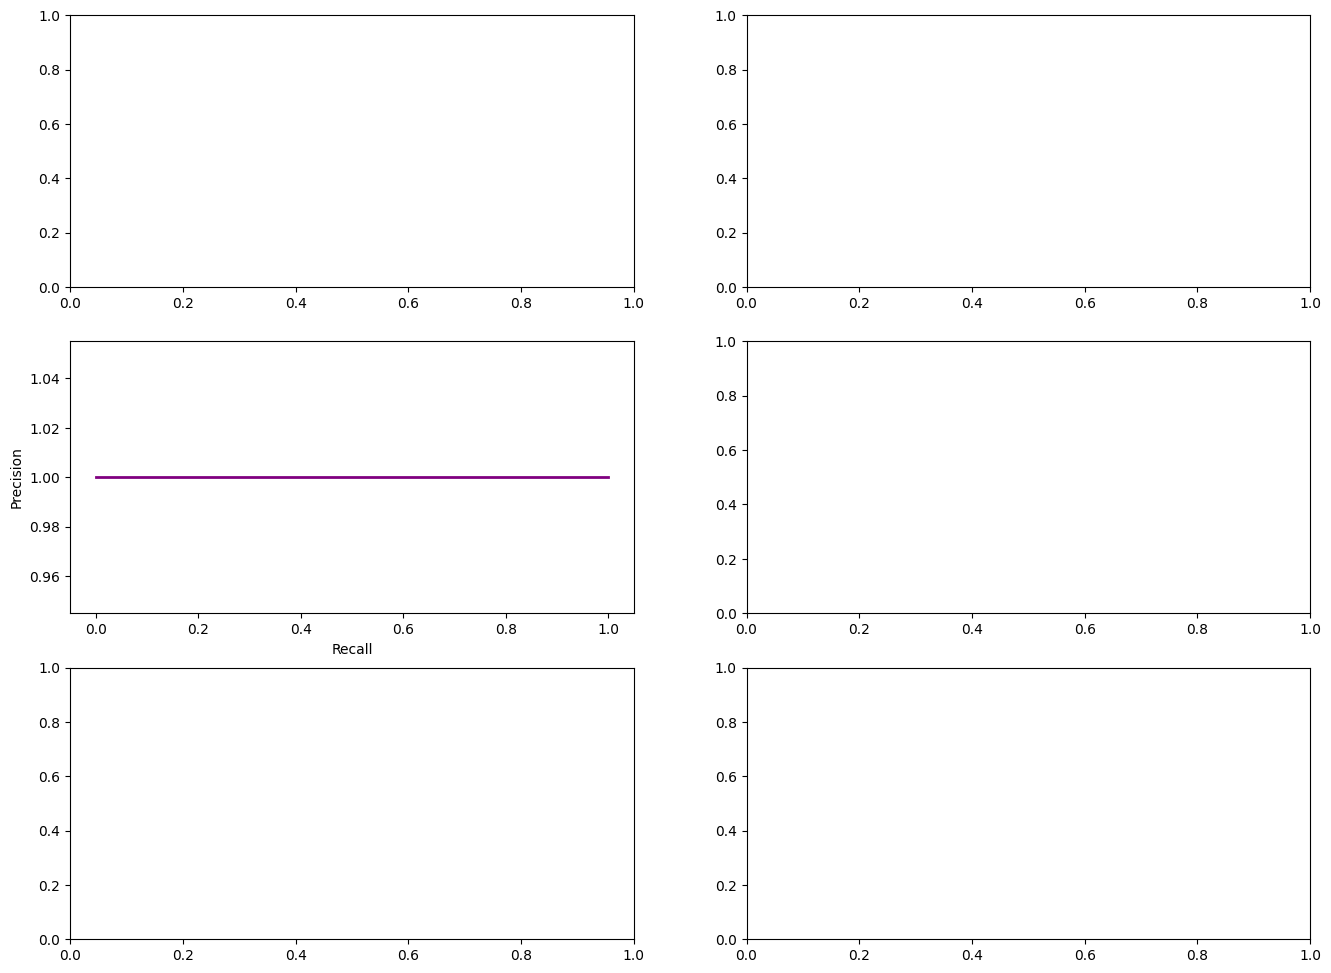

In [ ]:
print("\n" + "="*60)
print("Creating visualizations...")
print("="*60 + "\n")

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# 1. ROC Curve - Overall
if len(np.unique(true_labels)) > 1:
    fpr_overall, tpr_overall, _ = roc_curve(true_labels, reconstruction_scores)
    axes[0, 0].plot(fpr_overall, tpr_overall, linewidth=2, label=f'Overall (AUC={roc_auc_overall:.3f})')
    axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[0, 0].set_xlabel('False Positive Rate')
    axes[0, 0].set_ylabel('True Positive Rate')
    axes[0, 0].set_title('ROC Curve - Overall Error')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. ROC Curve - Coolant
    fpr_coolant, tpr_coolant, _ = roc_curve(true_labels, coolant_scores)
    axes[0, 1].plot(fpr_coolant, tpr_coolant, linewidth=2, color='red', label=f'Coolant (AUC={roc_auc_coolant:.3f})')
    axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[0, 1].set_xlabel('False Positive Rate')
    axes[0, 1].set_ylabel('True Positive Rate')
    axes[0, 1].set_title('ROC Curve - Coolant Error')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(true_labels, coolant_scores)
axes[1, 0].plot(recall, precision, linewidth=2, color='purple')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title(f'Precision-Recall Curve (AP={ap_coolant:.3f})')
axes[1, 0].grid(True, alpha=0.3)

# 4. Anomaly Score Distribution
axes[1, 1].hist(coolant_scores[true_labels == 0], bins=30, alpha=0.6, label='Normal', color='blue')
axes[1, 1].hist(coolant_scores[true_labels == 1], bins=30, alpha=0.6, label='Anomaly', color='red')
axes[1, 1].axvline(optimal_threshold, color='black', linestyle='--', linewidth=2, label='Threshold')
axes[1, 1].set_xlabel('Coolant Reconstruction Error')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Score Distribution')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Confusion Matrix Heatmap
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
im = axes[2, 0].imshow(cm_normalized, cmap='Blues')
axes[2, 0].set_xticks([0, 1])
axes[2, 0].set_yticks([0, 1])
axes[2, 0].set_xticklabels(['Normal', 'Anomaly'])
axes[2, 0].set_yticklabels(['Normal', 'Anomaly'])
axes[2, 0].set_xlabel('Predicted')
axes[2, 0].set_ylabel('True')
axes[2, 0].set_title('Confusion Matrix (Normalized)')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = axes[2, 0].text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.2%})',
                              ha="center", va="center", color="white" if cm_normalized[i, j] > 0.5 else "black")

plt.colorbar(im, ax=axes[2, 0])

# 6. Score Timeline
axes[2, 1].plot(coolant_scores, alpha=0.7, linewidth=1, label='Anomaly Score')
axes[2, 1].axhline(optimal_threshold, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[2, 1].scatter(
    np.where(true_labels == 1)[0],
    coolant_scores[true_labels == 1],
    color='red', s=50, marker='x', label='True Anomalies', zorder=5
)
axes[2, 1].set_xlabel('Window Index')
axes[2, 1].set_ylabel('Coolant Error')
axes[2, 1].set_title('Anomaly Scores Over Time')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Evaluation plots saved to ./evaluation_results.png")
